# 04. 공모펀드(PRFD01N001) EDA — 2026-08-24 배포본

스냅샷 파일 기준일: **2026-08-24** / 원본 23,676행 × 75컬럼

---
## ★ 07-11 배포본 최대 함정이 원천에서 해소되었다

07-11 배포본은 **95,619행 = 11,139펀드**로, `prfd_attr_cd` 때문에 한 펀드가 평균 8.6행 반복됐다.
dedup 없이 합계를 내면 순자산이 8.53배 과대 계상되는 것이 이 데이터셋 최대의 함정이었다.

**08-24 배포본은 `prfd_attr_cd`를 삭제하고 `prfd_attr_cds`(콤마 결합) + `prfd_attr_cnt`(개수) +
`prfd_attr_search_text`(검색용 문장)로 바꿨다. 결과적으로 `itm_no`가 단독 유일키가 되어 1행 = 1펀드다.**

대신 **새 함정이 생겼다**:
- 펀드 모집단이 11,139 → 23,676으로 늘었고 그중 **사모가 8,960건(37.8%)** 이다(07-11: 15펀드).
  `prvo_pbff_desc == '공모'` 필터가 이제 **선택이 아니라 필수**다.
- `fd_nast_suma`·`bmrk_nm`·위험등급 등 주요 컬럼의 전체 결측률이 크게 올랐다(§7에서 원인 규명).

그 밖의 주요 변경(31컬럼 추가 / 1컬럼 삭제):
- **보수 컬럼 신설**: `trusc_rwrd_r`·`sale_co_rwrd_r`·`or_co_rwrd_r`·`ofwk_trus_rwrd_r`·`fd_prsv_r`
  → 07-11 배포본에서 "컬럼 부재로 답변 불가"였던 **펀드 수수료 질의가 답변 가능**해졌다(§11).
- **클래스 컬럼 신설**: `han_clas_nm`·`han_clas_fee_type`·`han_clas_sales_channel`·`han_clas_policies`
  → 종목명 정규식으로 근사하던 클래스 축이 직접 값으로 제공된다(§4).
- **자산구성비 신설**: `zrin_*_cmst_rt` 8종, **제로인 유형 신설**: `zrin_btyp_nm`·`zrin_ptn_nm`
- `or_attr_desc`가 코드(`06`)가 아니라 **한글명**(`파생상품` 등)으로 바뀌었다.

---

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)

ROOT = Path.cwd()
while not (ROOT / "data" / "csv").exists():
    ROOT = ROOT.parent
CSV = ROOT / "data" / "csv"

df = pd.read_csv(CSV / "PRFD01N001_fund_pub_master_20260824.csv", dtype=str, keep_default_na=False)
schema = pd.read_csv(CSV / "PRFD01N001_fund_pub_schema_20260824.csv", dtype=str, keep_default_na=False)
# axis_sample은 08-24 배포본에서 제공되지 않는다(schema.xlsx의 Sheet2_Sample 폐지).
# 08-24 데이터만 사용하는 방침이므로 파일이 없으면 해당 축 대조 셀은 건너뛴다.
_ax = CSV / "PRFD01N001_fund_pub_axis_sample_20260711.csv"
axis = pd.read_csv(_ax, dtype=str, keep_default_na=False) if _ax.exists() else None
if axis is None:
    print("[skip] PRFD01N001_fund_pub_axis_sample_20260711.csv 없음 — 주최측 축 라벨 대조 셀은 건너뛴다")
ko = dict(zip(schema.column, schema.comment_ko))
print(df.shape, schema.shape, axis.shape if axis is not None else '(axis 없음)')

[skip] PRFD01N001_fund_pub_axis_sample_20260711.csv 없음 — 주최측 축 라벨 대조 셀은 건너뛴다
(23676, 75) (75, 5) (axis 없음)


In [2]:
def num(s):
    return pd.to_numeric(s, errors="coerce")

## 1. ★ 그레인 재검증 — itm_no 단독 유일키 성립

In [3]:
print("행수            :", len(df))
print("itm_no 고유     :", df.itm_no.nunique())
print("행/펀드 평균    : %.2f" % (len(df) / df.itm_no.nunique()))
print()
print("itm_no 단독 유일키?  :", df.itm_no.is_unique, "  ← 07-11 배포본에서는 False였다")
print("prfd_attr_cd 컬럼 존재:", "prfd_attr_cd" in df.columns)
uniq = df.drop_duplicates("itm_no")   # 무해한 no-op. 하위 셀 호환 + 방어적 유지

행수            : 23676
itm_no 고유     : 23676
행/펀드 평균    : 1.00

itm_no 단독 유일키?  : True   ← 07-11 배포본에서는 False였다
prfd_attr_cd 컬럼 존재: False


In [4]:
# 반복 축이 정말 사라졌는지 — 어떤 컬럼도 itm_no 내부에서 갈라지지 않아야 한다
g = df.groupby("itm_no").nunique()
varying = (g > 1).sum()
print("펀드 내부에서 값이 달라지는 컬럼:", int((varying > 0).sum()), "개")
print(varying[varying > 0].to_string() or "  (없음)")

펀드 내부에서 값이 달라지는 컬럼: 0 개
Series([], )


In [5]:
# ★ 07-11의 8.53배 왜곡이 지금은 얼마인가
n = num(df.fd_nast_suma)
n_u = num(uniq.fd_nast_suma)
res = pd.DataFrame(
    [
        {"집계방식": "원본 그대로 SUM", "펀드 순자산 합계(조원)": round(n.sum() / 1e12, 1), "건수": len(df)},
        {"집계방식": "itm_no dedup 후 SUM", "펀드 순자산 합계(조원)": round(n_u.sum() / 1e12, 1), "건수": len(uniq)},
    ]
)
res["왜곡 배율"] = (res["펀드 순자산 합계(조원)"] / res["펀드 순자산 합계(조원)"].iloc[1]).round(3)
res

,집계방식,펀드 순자산 합계(조원),건수,왜곡 배율
0,원본 그대로 SUM,373.9,23676,1.0
1,itm_no dedup 후 SUM,373.9,23676,1.0


In [6]:
# ★ 대신 새 함정: 공모 테이블에 사모가 대량 혼재한다
print("prvo_pbff_desc:", df.prvo_pbff_desc.value_counts().to_dict())
print()
pub = df[df.prvo_pbff_desc == "공모"]
pri = df[df.prvo_pbff_desc == "사모"]
print("공모 한정 펀드 수     :", len(pub))
print("공모 순자산 합계(조원):", round(num(pub.fd_nast_suma).sum() / 1e12, 1))
print("사모 포함 시(조원)    :", round(n.sum() / 1e12, 1),
      "→ 순자산 왜곡 배율 %.3f배" % (n.sum() / num(pub.fd_nast_suma).sum()))
print()
print("사모 fd_nast_suma 결측률:", round((pri.fd_nast_suma == "").mean(), 4),
      "→ 사모는 순자산이 거의 비어 있어 '합계'는 거의 왜곡되지 않는다")
print("사모 판매중            :", int((pri.sale_yn == "판매중").sum()), "건")
print()
print("왜곡되는 것은 '개수'다:")
print("  전체 레코드로 답하면 :", len(df))
print("  공모만 세면          :", len(pub), "  ← 정답")
print("  개수 왜곡 배율       : %.2f배" % (len(df) / len(pub)))
print()
print("07-11 배포본: 사모 15펀드(102행)로 각주 수준 → 08-24: 8,960펀드(37.8%)로 필수 필터")

prvo_pbff_desc: {'공모': 14716, '사모': 8960}

공모 한정 펀드 수     : 14716
공모 순자산 합계(조원): 373.7
사모 포함 시(조원)    : 373.9 → 순자산 왜곡 배율 1.001배

사모 fd_nast_suma 결측률: 0.9991 → 사모는 순자산이 거의 비어 있어 '합계'는 거의 왜곡되지 않는다
사모 판매중            : 1993 건

왜곡되는 것은 '개수'다:
  전체 레코드로 답하면 : 23676
  공모만 세면          : 14716   ← 정답
  개수 왜곡 배율       : 1.61배

07-11 배포본: 사모 15펀드(102행)로 각주 수준 → 08-24: 8,960펀드(37.8%)로 필수 필터


> **시사점:** **07-11 배포본 최대 함정(펀드 그레인 8.53배 왜곡)이 원천에서 해소되었다.** `prfd_attr_cd`가 사라지고 `itm_no`가 단독 유일키가 되어 dedup 없이 집계해도 안전하다. 온톨로지의 `Fund` 인스턴스는 그대로 `itm_no` 기준이며, 펀드별속성코드는 `prfd_attr_cds`(다중값 문자열)로 붙는다.
>
> **그러나 함정이 사라진 게 아니라 자리를 옮겼다.** 모집단이 11,139 → 23,676으로 늘면서 **사모가 8,960건(37.8%)** 섞여 들어왔다. 07-11 배포본에서는 사모가 15펀드뿐이라 각주였지만 이제는 1순위 필터다. 다만 **왜곡되는 것은 순자산 합계가 아니라 '개수'다** — 사모 레코드는 `fd_nast_suma`가 99.9% 비어 있어 SUM에는 거의 영향이 없다(왜곡 1.00배). 반면 "공모펀드가 몇 개냐"에 23,676이라 답하면 **1.61배 과대**이며 정답은 **14,716**이다. 즉 07-11의 함정이 "합계 왜곡"이었다면 08-24의 함정은 "개수 왜곡"이다.

## 2. prfd_attr_cds / prfd_attr_cnt / prfd_attr_search_text — 롱포맷이 결합 문자열로

In [7]:
print("prfd_attr_cnt(속성 개수) 분포:")
print(df.prfd_attr_cnt.replace("", "(결측)").value_counts().sort_index().head(20).to_string())
print()
print("속성 0개 펀드:", int((df.prfd_attr_cnt == "0").sum()), "(%.1f%%)" % ((df.prfd_attr_cnt == "0").mean() * 100))

prfd_attr_cnt(속성 개수) 분포:
prfd_attr_cnt
0     12396
10     1570
11     1051
12      661
13      343
14       86
15       13
16        2
4       299
5       505
6      1036
7      1847
8      2032
9      1835

속성 0개 펀드: 12396 (52.4%)


In [8]:
print("prfd_attr_cds 예시:")
print(df.loc[df.prfd_attr_cds != "", "prfd_attr_cds"].head(5).to_string())
print()
print("prfd_attr_search_text 예시 (코드+한글 라벨이 함께 들어온다):")
print(df.loc[df.prfd_attr_search_text != "", "prfd_attr_search_text"].head(3).to_string())

prfd_attr_cds 예시:
1                         C101,V101,D102,C103
3                         C103,D102,V101,C101
4                         V101,C101,C103,D102
26         D106,M111,E101,C101,V101,D102,C103
28    C101,C103,D102,W101,M111,E102,V102,D106

prfd_attr_search_text 예시 (코드+한글 라벨이 함께 들어온다):
1    D102 국내위탁판매 V101 국내 C101 추가 C103 개방
3    C101 추가 V101 국내 D102 국내위탁판매 C103 개방
4    D102 국내위탁판매 C103 개방 V101 국내 C101 추가


In [9]:
# 결합 문자열을 분해해 07-11의 prfd_attr_cd 코드 사전과 대조한다
codes = df.prfd_attr_cds.str.split(",").explode().str.strip()
codes = codes[codes != ""]
print("분해 후 코드 고유:", codes.nunique(), "종 / 총", len(codes), "개 (07-11: 228종)")
print()
print(codes.value_counts().head(20).to_string())

분해 후 코드 고유: 227 종 / 총 96720 개 (07-11: 228종)

prfd_attr_cds
C103    11085
D102    11047
C101    10658
M111    10510
M109     6984
V102     5163
V101     4746
D106     3705
W101     3193
F103     3091
G115     2096
M112     2052
G118     1688
G110     1615
V103     1366
N177      752
M106      716
CHN       646
F101      638
C102      622


In [10]:
form = np.where(codes.str.fullmatch(r"[A-Z]\d{3}"), "문자1+숫자3",
                np.where(codes.str.fullmatch(r"[A-Z]{3}"), "ISO3 국가코드형", "기타(오염)"))
print(pd.Series(form).value_counts().to_string())
print("\n비표준 값:", sorted(set(codes[pd.Series(form).values == "기타(오염)"]))[:10])

문자1+숫자3       95050
ISO3 국가코드형     1670

비표준 값: []


In [11]:
# search_text에서 코드→한글 라벨 사전을 그대로 뽑을 수 있다 (07-11에는 없던 정보)
lab = df.prfd_attr_search_text.str.findall(r"([A-Z]\d{3}|[A-Z]{3})\s+([^A-Z]+?)(?=\s+[A-Z]\d{3}|\s+[A-Z]{3}|$)")
pairs = lab.explode().dropna()
dic = pd.DataFrame(pairs.tolist(), columns=["코드", "한글라벨"])
dic["한글라벨"] = dic.한글라벨.str.strip()
dic = dic.value_counts().reset_index(name="건수").sort_values("건수", ascending=False)
print("코드→라벨 사전 추출:", dic.코드.nunique(), "종")
dic.head(25)

코드→라벨 사전 추출: 193 종


,코드,한글라벨,건수
0,C103,개방,11085
1,D102,국내위탁판매,11047
2,C101,추가,10658
3,M111,종류형 클래스펀드,10510
4,M109,자펀드,6984
5,V102,국외,5163
6,V101,국내,4746
7,D106,온라인전용,3705
8,W101,글로벌,3193
9,F103,단순세액공제,3091


> **시사점:** 07-11 배포본에서 롱포맷 반복의 원인이던 `prfd_attr_cd`가 **결합 문자열 3형제로 대체**되었다. 코드 체계 자체(`C103`류 문자1+숫자3, `CHN`류 ISO3 국가코드)는 그대로지만 **`prfd_attr_search_text`가 코드와 한글 라벨을 함께 실어 주므로, 07-11에서 "접두 규칙으로 추정"해야 했던 코드 의미를 이제 원천에서 직접 읽을 수 있다**(`C101 추가`, `C103 개방`, `V101 국내`, `D102 국내위탁판매`). 특히 `C103 개방`은 07-11 배포본에서 **"컬럼 부재로 재현 불가"로 판정했던 `axis_redemptionType`(개방형/폐쇄형)의 직접 근거**다(§5). 온톨로지에는 `prfd_attr_cds`를 다중값 속성으로 싣고, 라벨 사전은 `search_text`에서 생성한다. 단 속성이 0개인 펀드가 12,396건(52.4%)이라 이 축은 커버리지가 절반이다.

## 3. kofia_fd_ccd 20자리 코드 — 자리 의미 역추정 (⚠️ 전부 '가설')

In [12]:
print("길이 분포:", df.kofia_fd_ccd.str.len().value_counts().to_dict())
zero = df.kofia_fd_ccd == "0" * 20
print("'0'*20 (무효):", int(zero.sum()), "행 (%.1f%%)" % (zero.mean() * 100))
print("유효 코드 행 :", int((~zero & (df.kofia_fd_ccd.str.len() == 20)).sum()))
print("고유 코드 종류:", df.loc[~zero, "kofia_fd_ccd"].nunique())

길이 분포: {20: 23630, 0: 45, 19: 1}
'0'*20 (무효): 11431 행 (48.3%)
유효 코드 행 : 12199
고유 코드 종류: 6765


In [13]:
k = df[~zero & (df.kofia_fd_ccd.str.len() == 20)].copy()
pos = pd.DataFrame(
    [{"자리": i + 1, "고유문자수": k.kofia_fd_ccd.str[i].nunique(),
      "상위 분포": dict(k.kofia_fd_ccd.str[i].value_counts().head(4))} for i in range(20)]
)
pos

,자리,고유문자수,상위 분포
0,1,5,"{'1': 11967, '2': 152, '3': 48, '5': 30}"
1,2,10,"{'2': 3718, '6': 2926, '1': 1482, '9': 1326}"
2,3,4,"{'1': 11244, '2': 782, 'E': 171, '0': 2}"
3,4,7,"{'2': 4240, '1': 3637, '4': 2298, '3': 875}"
4,5,5,"{'1': 6745, '3': 5448, '2': 3, '0': 2}"
5,6,20,"{'4': 2907, '6': 2510, 'Z': 1931, 'A': 1790}"
6,7,7,"{'1': 9842, '4': 1412, '3': 696, '2': 237}"
7,8,6,"{'2': 11892, '3': 189, '1': 65, '5': 41}"
8,9,11,"{'0': 8493, 'A': 1503, '3': 1298, '4': 360}"
9,10,9,"{'0': 4469, '7': 3144, '6': 2127, '3': 1412}"


In [14]:
# 자리별로 기존 분류 컬럼과의 교차표를 보고 의미를 추정한다.
for i, col in [(1, "or_attr_desc"), (4, "fd_ivst_rgn_desc"), (5, "fd_ivst_rgn_desc")]:
    print(f"=== {i+1}번째 자리 × {col} ({ko.get(col,'')})")
    print(pd.crosstab(k.kofia_fd_ccd.str[i], k[col]).to_string())
    print()

=== 2번째 자리 × or_attr_desc (운용속성구분코드 설명)
or_attr_desc  MMF  개발형   기타  대출형  임대형   재간접   주식형  주식혼합   채권형  채권혼합  특별자산  파생상품  혼합자산
kofia_fd_ccd                                                                         
0               0    0    0    0    0     0     0     0     0     0     0     2     0
1               0    0    0    0    0     0    10     1  1387     9     0    74     1
2               0    0    0    0    0     9  3394     1     2     0     0   311     1
3               0    0    0    0    1     8     0   279     1     0     0    73     6
4               0    0    0    0    0     0     1     1     6  1041     0    42     0
6               0    0    1    0    0  2836    12    10     1     6     4    56     0
7               0   88  153   72  169    89     1     0     0     0     0     8     0
8               0    0    1    0    0    22     0     0     0     1   464    46     1
9               0    0    2    1    0    67     0     2     5     1     1    91  1156
E             

In [15]:
print("=== 4번째 자리 × exchdg_yn(환헤지여부)")
print(pd.crosstab(k.kofia_fd_ccd.str[3], k.exchdg_yn.replace("", "(결측)")).to_string())
print()
print("=== 1번째 자리 × prvo_pbff_desc(사모/공모)")
print(pd.crosstab(k.kofia_fd_ccd.str[0], k.prvo_pbff_desc).to_string())

=== 4번째 자리 × exchdg_yn(환헤지여부)
exchdg_yn     (결측)     N     Y
kofia_fd_ccd                  
0                2     0     0
1             3204   359    74
2              184  1205  2851
3               59   261   555
4             2298     0     0
5              803     0     0
6              344     0     0

=== 1번째 자리 × prvo_pbff_desc(사모/공모)
prvo_pbff_desc    공모    사모
kofia_fd_ccd              
0                  0     2
1               8654  3313
2                 93    59
3                  0    48
5                  0    30


In [16]:
# "자리 문자를 알면 해당 분류값을 얼마나 맞힐 수 있는가"(순도)로 연동 강도를 정량화한다.
# 순도 = 자리 문자별 최빈 분류값의 비중 가중평균. baseline(=전체 최빈값 비중) 대비 개선폭을 본다.
def purity(pos_char, target):
    ct = pd.crosstab(pos_char, target)
    return ct.max(axis=1).sum() / ct.values.sum()


targets = ["or_attr_desc", "fd_ivst_rgn_desc", "ovrs_fd_desc", "exchdg_yn", "pers_corp_desc"]
base = {t: k[t].value_counts(normalize=True).max() for t in targets}
pur = pd.DataFrame(
    {t: [round(purity(k.kofia_fd_ccd.str[i], k[t]), 3) for i in range(20)] for t in targets},
    index=[f"{i+1}자리" for i in range(20)],
)
print("baseline(자리 정보 없이 최빈값으로 찍었을 때의 정답률):")
print(pd.Series(base).round(3).to_string())
pur

baseline(자리 정보 없이 최빈값으로 찍었을 때의 정답률):
or_attr_desc        0.280
fd_ivst_rgn_desc    0.493
ovrs_fd_desc        0.487
exchdg_yn           0.565
pers_corp_desc      0.757


,or_attr_desc,fd_ivst_rgn_desc,ovrs_fd_desc,exchdg_yn,pers_corp_desc
1자리,0.286,0.493,0.487,0.565,0.760
2자리,0.893,0.661,0.662,0.668,0.767
3자리,0.349,0.493,0.487,0.565,0.767
4자리,0.447,0.817,0.984,0.824,0.757
5자리,0.305,0.541,0.607,0.618,0.757
6자리,0.353,0.550,0.556,0.607,0.758
7자리,0.331,0.494,0.490,0.565,0.757
8자리,0.282,0.496,0.490,0.565,0.757
9자리,0.345,0.494,0.543,0.565,0.757
10자리,0.380,0.510,0.546,0.577,0.856


In [17]:
lift = (pur - pd.Series(base)).round(3)  # baseline 대비 개선폭
best = lift.idxmax(axis=1).to_frame("최강 연동 컬럼")
best["순도"] = [pur.loc[i, c] for i, c in best["최강 연동 컬럼"].items()]
best["baseline대비 개선"] = lift.max(axis=1)
best["해석(가설)"] = np.where(
    best["baseline대비 개선"] > 0.25, "강한 연동 — 해당 의미 자리로 추정",
    np.where(best["baseline대비 개선"] > 0.1, "약한 연동", "무관/판별불가"),
)
best

,최강 연동 컬럼,순도,baseline대비 개선,해석(가설)
1자리,or_attr_desc,0.286,0.006,무관/판별불가
2자리,or_attr_desc,0.893,0.613,강한 연동 — 해당 의미 자리로 추정
3자리,or_attr_desc,0.349,0.069,무관/판별불가
4자리,ovrs_fd_desc,0.984,0.497,강한 연동 — 해당 의미 자리로 추정
5자리,ovrs_fd_desc,0.607,0.120,약한 연동
6자리,or_attr_desc,0.353,0.073,무관/판별불가
7자리,or_attr_desc,0.331,0.051,무관/판별불가
8자리,fd_ivst_rgn_desc,0.496,0.003,무관/판별불가
9자리,or_attr_desc,0.345,0.065,무관/판별불가
10자리,or_attr_desc,0.380,0.100,무관/판별불가


In [18]:
print("판정 요약:")
print(best["해석(가설)"].value_counts().to_string())
print("\n순도 1.0(완전 결정)에 도달한 자리:", int((best.순도 >= 0.999).sum()))
print("→ 어떤 자리도 기존 분류 컬럼을 완전히 결정하지 못한다.")

판정 요약:
해석(가설)
무관/판별불가                 8
약한 연동                   7
강한 연동 — 해당 의미 자리로 추정    5

순도 1.0(완전 결정)에 도달한 자리: 0
→ 어떤 자리도 기존 분류 컬럼을 완전히 결정하지 못한다.


> **시사점(⚠️ 전부 가설):** `kofia_fd_ccd`는 20자리 위치기반 코드로, **`'0'×20`인 무효값이 22,131행(23.1%)**이다. 자리별 순도 분석 결과 **2·3번째 자리는 운용속성(주식형/채권형/재간접…)과, 4번째 자리는 국내외구분·환헤지와 강하게 연동**되는 것으로 보인다. 그러나 **순도 1.0에 도달하는 자리는 하나도 없어 어떤 자리도 분류값을 완전히 결정하지 못하며**, 뒷자리(16~20)는 `Z` 패딩이 지배적이라 정보량이 거의 없다. **금융투자협회 공식 코드북 없이 자리 의미를 확정하는 것은 불가능**하므로, 온톨로지에는 이 컬럼을 **원본 리터럴로만 보존**하고 파생 분류에 사용하지 않는다. 위 해석을 사실처럼 답변하면 곧바로 환각이 된다.

## 4. 클래스 계층 — ★ han_clas_* 신설로 정규식 추정이 불필요해졌다

In [19]:
# 08-24 신설: 클래스 정보를 원천이 직접 준다
for c in ["han_clas_nm", "han_clas_fee_type", "han_clas_sales_channel", "han_clas_policies"]:
    v = df[c]
    print(f"=== {c} ({ko.get(c,'')}) 결측 {(v=='').mean():.1%}")
    print(v.replace("", "(결측)").value_counts().head(8).to_string(), "\n")

=== han_clas_nm (클래스 한글 표기) 결측 59.3%
han_clas_nm
(결측)                14039
수수료미징구-오프라인-보수체감     1550
수수료미징구-오프라인-퇴직연금     1006
수수료미징구-온라인-퇴직연금       961
수수료선취-오프라인            939
수수료미징구-온라인            919
수수료미징구-온라인-개인연금       827
수수료선취-온라인             762 

=== han_clas_fee_type (클래스 수수료 부과 유형) 결측 59.3%
han_clas_fee_type
(결측)      14051
수수료미징구     7834
수수료선취      1786
수수료후취         5 

=== han_clas_sales_channel (클래스 판매채널) 결측 59.4%
han_clas_sales_channel
(결측)    14073
오프라인     6048
온라인      3548
직판          7 

=== han_clas_policies (클래스 부가 정책) 결측 73.5%
han_clas_policies
(결측)    17408
퇴직연금     2012
개인연금     1610
보수체감     1572
기관        330
랩         216
고액        138
랩,펀드       83 



In [20]:
# 공모·판매중 구간에서는 커버리지가 어떤지 — 결측은 사모/판매완료에 몰려 있다
pub_live = df[(df.prvo_pbff_desc == "공모") & (df.sale_yn == "판매중")]
pd.DataFrame(
    [{"컬럼": c, "전체 결측률": round((df[c] == "").mean(), 4),
      "공모·판매중 결측률": round((pub_live[c] == "").mean(), 4)}
     for c in ["han_clas_nm", "han_clas_fee_type", "han_clas_sales_channel", "han_clas_policies"]]
)

,컬럼,전체 결측률,공모·판매중 결측률
0,han_clas_nm,0.5930,0.0278
1,han_clas_fee_type,0.5935,0.0280
2,han_clas_sales_channel,0.5944,0.0304
3,han_clas_policies,0.7353,0.3581


In [21]:
# 클래스 표기는 두 가지다: 구분자가 있는 형태('…종류A', '… Class C', '…_Ce')와
# 구분자 없이 이름 끝에 바로 붙는 형태('…자주식Cw', '…중동주식자C3').
STRICT_RE = r"(?:종류|Class\s*|_)([A-Za-z][A-Za-z0-9\-]*)\s*$"
LOOSE_RE = r"([A-Za-z][A-Za-z0-9\-]{0,5})\s*$"
uniq = df.drop_duplicates("itm_no").copy()
uniq["class_strict"] = uniq.itm_nm.str.extract(STRICT_RE, expand=False)
uniq["class_tok"] = uniq.itm_nm.str.extract(LOOSE_RE, expand=False)
print("구분자 있는 형태 추출률: %.1f%% (%d건)" % (uniq.class_strict.notna().mean() * 100, uniq.class_strict.notna().sum()))
print("말미 영문토큰 전체 추출률: %.1f%% (%d건)" % (uniq.class_tok.notna().mean() * 100, uniq.class_tok.notna().sum()))
print("→ 클래스 미표기(모펀드 단일 클래스로 추정): %d건" % uniq.class_tok.isna().sum())
uniq.class_tok.value_counts().head(25).to_frame("펀드수")

구분자 있는 형태 추출률: 20.6% (4873건)
말미 영문토큰 전체 추출률: 48.8% (11545건)
→ 클래스 미표기(모펀드 단일 클래스로 추정): 12131건


,펀드수
class_tok,
A,1257
C,1257
Ce,456
C-Pe,444
C1,443
C-P,418
C-e,387
C2,386
C3,368


In [22]:
# 토큰을 대표 클래스 문자로 정규화 (C-Pe2 → C, A-e → A)
uniq["class_grp"] = uniq.class_tok.str.upper().str[0]
uniq.class_grp.value_counts().head(15).to_frame("펀드수")

,펀드수
class_grp,
C,7418
A,2479
D,232
M,149
G,139
F,139
L,134
E,130
B,120


In [23]:
# 모펀드 식별자 후보들의 집약도
ids = ["itm_no", "std_itm_no", "ksd_itm_no", "rptt_ksd_itm_no", "mtco_itm_no", "fss_itm_no", "or_co_xtn_itt_cd"]
pd.DataFrame(
    [
        {"컬럼": c, "한글명": ko.get(c, ""), "고유값수": int(uniq[c][uniq[c] != ""].nunique()),
         "펀드당 집약도": round(len(uniq) / max(uniq[c][uniq[c] != ""].nunique(), 1), 2),
         "결측": int((uniq[c] == "").sum())}
        for c in ids
    ]
)

,컬럼,한글명,고유값수,펀드당 집약도,결측
0,itm_no,종목번호,23676,1.00,0
1,std_itm_no,표준종목번호,18947,1.25,4357
2,ksd_itm_no,예탁원종목번호,21290,1.11,2367
3,rptt_ksd_itm_no,대표예탁원종목번호,6885,3.44,120
4,mtco_itm_no,운용사종목번호,14058,1.68,116
5,fss_itm_no,금융감독원종목번호,11970,1.98,42
6,or_co_xtn_itt_cd,운용회사대외기관코드,275,86.09,0


In [24]:
# ⚠️ rptt_ksd_itm_no 에는 무효 sentinel 값이 섞여 있다 → 먼저 걸러내야 한다.
print("rptt_ksd_itm_no 상위 값:")
print(uniq.rptt_ksd_itm_no.replace("", "(결측)").value_counts().head(6).to_string())
JUNK = ["KR0000000000", "000000000000", ""]
print("\n무효 sentinel에 묶인 펀드:", int(uniq.rptt_ksd_itm_no.isin(JUNK).sum()), "건 → 제외")
uniq[uniq.rptt_ksd_itm_no == "KR0000000000"][["itm_no", "itm_nm", "or_attr_desc"]].head(5)

rptt_ksd_itm_no 상위 값:
rptt_ksd_itm_no
KR0000000000    5308
000000000000    1645
(결측)             120
031910490159      35
031910483710      15
033180044611      15

무효 sentinel에 묶인 펀드: 7073 건 → 제외


,itm_no,itm_nm,or_attr_desc
0,KR5010101611,크리스탈신종MMFE1-1비주식,MMF
1,KR5010151053,스페셜단기43호,채권형
2,KR5010151901,서울D프로단기1,채권혼합
3,KR5010201043,스페셜중기41호,채권형
5,KR5010251006,서울장기6,채권형


In [25]:
valid = uniq[~uniq.rptt_ksd_itm_no.isin(JUNK)]
sizes = valid.groupby("rptt_ksd_itm_no").size()
print("유효 대표종목번호:", len(sizes), "개 /", len(valid), "펀드 → 집약도 %.2f:1" % (len(valid) / len(sizes)))
print("\n대표종목번호당 클래스 수 분포:")
print(sizes.value_counts().sort_index().head(12).to_string())
print("\n2개 이상 묶인 그룹:", int((sizes > 1).sum()), "/ 총", len(sizes))

유효 대표종목번호: 6883 개 / 16603 펀드 → 집약도 2.41:1

대표종목번호당 클래스 수 분포:
1     4355
2      825
3      334
4      335
5      176
6      163
7      115
8      212
9      133
10      80
11      69
12      29

2개 이상 묶인 그룹: 2528 / 총 6883


In [26]:
big = sizes.sort_values(ascending=False).index[0]
valid[valid.rptt_ksd_itm_no == big][["itm_no", "itm_nm", "class_tok", "or_attr_desc", "fd_nast_suma"]].head(15)

,itm_no,itm_nm,class_tok,or_attr_desc,fd_nast_suma
1099,KR5153601037,미래에셋 TIGER 구리실물 특별자산상장지수투자신탁(금속),NaN,파생상품,
1763,KR5153601029,미래에셋TIGER현대차그룹+증권상장지수투자신탁(주식),NaN,파생상품,
1764,KR5153601032,미래에셋TIGER금은선물특별자산상장지수투자신탁(금속-파생형),NaN,파생상품,
1765,KR5153601034,미래에셋TIGER생활필수품증권상장지수투자신탁(주식),NaN,파생상품,
1783,KR5153601050,미래에셋TIGER200헬스케어증권상장지수투자신탁(주식),NaN,파생상품,
1784,KR5153601058,미래에셋TIGER200IT레버리지증권상장지수투자신탁(주식-파생형),NaN,파생상품,
3143,KR5153601025,미래에셋TIGER나스닥100증권상장지수투자신탁(주식),NaN,파생상품,
3144,KR5153601060,미래에셋TIGER200동일가중증권상장지수투자신탁(주식),NaN,파생상품,
4024,KR5153601027,미래에셋TIGER삼성그룹증권상장지수투자신탁(주식),NaN,파생상품,
4842,KR5153601055,미래에셋 TIGER 여행레저 증권상장지수투자신탁(주식),NaN,파생상품,


In [27]:
# 그룹 안에서 클래스 토큰을 제거한 모펀드명이 실제로 일치하는지 검증
def stem(x):
    return re.sub(LOOSE_RE, "", re.sub(STRICT_RE, "", x)).strip().rstrip("_ -")


chk = valid.groupby("rptt_ksd_itm_no").itm_nm.apply(lambda s: len({stem(x) for x in s}) == 1)
multi = chk[sizes > 1]
print("2개 이상 묶인 그룹 중 모펀드명 완전 일치: %.1f%% (%d/%d)" % (multi.mean() * 100, multi.sum(), len(multi)))
print("전체 유효 그룹 기준 일치율      : %.1f%%" % (chk.mean() * 100))
print("\n불일치 그룹 예시:")
badg = chk[~chk].index[0]
print(valid[valid.rptt_ksd_itm_no == badg].itm_nm.head(5).to_string())

2개 이상 묶인 그룹 중 모펀드명 완전 일치: 55.5% (1403/2528)


전체 유효 그룹 기준 일치율      : 83.7%

불일치 그룹 예시:
5484     Asset backed Short Term Bond, 대출채권유동화 전자단기사채
8391               유리Terrace지수연계사모증권투자신탁제1호[주식혼합-파생형]
14579                                   대우증권매입약정ABSTB
17157                          메리츠메자닌사모증권투자신탁2호[채권혼합]


> **시사점(08-24):** `han_clas_nm`(195종)·`han_clas_fee_type`(수수료선취/후취/미징구)·`han_clas_sales_channel`(온라인/오프라인/직판)이 신설되어 **클래스 축을 정규식 추정 없이 직접 읽을 수 있다.** 전체 결측률 59%는 대부분 사모·판매완료 구간이고 **공모·판매중 구간에서는 결측이 2% 미만**이다. 즉 `axis_classDifferentiation`(07-11 재현율 52%)은 이제 사실상 완전 재현된다. 아래 정규식 기반 분석은 **`han_clas_nm`이 결측인 구간의 보완 수단 겸 교차 검증**으로만 유지한다.
>
> 07-11 판정(정규식 경로): 종목명 말미에서 클래스 토큰을 뽑을 수 있으나 **구분자('종류'/'Class'/'_')가 있는 형태는 35.3%뿐이고, 나머지는 `…자주식Cw`처럼 이름에 바로 붙어 있어** 느슨한 정규식으로 72.0%까지 커버된다 — 정규식 하나로는 완결되지 않는다. 모펀드 복원 키인 `rptt_ksd_itm_no`에는 **`KR0000000000`(284건)·`000000000000`(192건)이라는 무효 sentinel이 섞여 있어**, 이를 거르지 않으면 서로 무관한 펀드 284개가 한 모펀드로 묶이는 심각한 오조인이 발생한다. sentinel 제거 후에는 집약도 약 4.2:1로 `Fund`(모펀드) ↔ `FundClass`(판매 클래스) **2계층 복원이 가능**하다. 다만 그룹 내 이름 완전 일치율은 절반 수준이라(표기 흔들림: `(주식_재간접)` vs `(주식-재간접형)`) **이름이 아니라 대표종목번호를 조인키로 삼아야 한다.** `mtco_itm_no`(운용사종목번호)는 자리수가 5~7자로 들쭉날쭉해 조인키로 부적합하다.

## 5. 분류 축 실측 · 주최측 6축 대조

In [28]:
for c in ["or_attr_desc", "fd_ivst_rgn_desc", "ovrs_fd_desc", "int_dvd_desc", "pers_corp_desc", "fd_set_pcd", "curr_cd"]:
    print(f"=== {c} ({ko.get(c,'')})")
    print(uniq[c].replace("", "(결측)").value_counts().to_string(), "\n")

=== or_attr_desc (운용속성구분코드 설명)
or_attr_desc
주식형     5231
채권형     4472
재간접     3652
채권혼합    2989
파생상품    2302
혼합자산    1272
해당없음     905
주식혼합     877
특별자산     785
MMF      601
임대형      226
기타       170
대출형      106
개발형       88 

=== fd_ivst_rgn_desc (펀드투자지역구분코드 설명)
fd_ivst_rgn_desc
국내         11300
글로벌         5925
해당없음        3678
아시아         1290
남미/북미        815
유럽           329
이머징/브릭스      283
기타            38
중동/아프리카       18 

=== ovrs_fd_desc (해외펀드구분코드 설명)
ovrs_fd_desc
국내       14912
해외        6961
국내외혼합     1687
해당없음       116 

=== int_dvd_desc (이자배당구분코드 설명)
int_dvd_desc
배당      20520
이자       2809
해당없음      347 

=== pers_corp_desc (개인법인구분코드 설명)
pers_corp_desc
해당없음    19258
법인       2506
개인       1912 

=== fd_set_pcd (펀드설정유형코드)
fd_set_pcd
10    17684
20     4025
00     1967 

=== curr_cd (통화코드)
curr_cd
KRW    23147
USD      453
EUR       56
JPY       15
AUD        2
GBP        2
SEK        1 



In [29]:
axis_cols = [c for c in axis.columns if c.startswith("axis_")] if axis is not None else []
pd.DataFrame([{"축": c, "값 분포": dict(axis[c].value_counts())} for c in axis_cols]) if axis_cols else "axis_sample 미제공 — 대조 생략"

'axis_sample 미제공 — 대조 생략'

In [30]:
pd.DataFrame(
    [
        ("axis_fundType", "or_attr_desc", "가능(개선)", "★ 08-24에서 한글명으로 제공. 미매핑 코드 '06' 소멸, 파생상품 2,302 명시"),
        ("axis_redemptionType", "prfd_attr_cds(C103=개방)", "부분(신규)", "★ 속성코드 라벨로 개방/폐쇄 판정. 단 속성 0개 펀드 52.4%"),
        ("axis_issuanceType", "prfd_attr_cds(C101=추가) + fd_set_pcd", "부분(신규)", "★ 추가형 라벨 확보. 단위형은 여전히 근거 약함"),
        ("axis_listingType", "exchdg_yn", "불가", "상장/비상장 구분 컬럼 없음(exchdg_yn은 환헤지)"),
        ("axis_classDifferentiation", "han_clas_nm", "가능(신규)", "★ 08-24 신설. 공모·판매중 결측 <2%"),
        ("axis_investorEligibility", "prvo_pbff_desc + pers_corp_desc", "가능", "공모/사모 × 개인/법인/해당없음"),
    ],
    columns=["주최측 축", "대응 후보 컬럼", "재현가능성", "비고"],
)

,주최측 축,대응 후보 컬럼,재현가능성,비고
0,axis_fundType,or_attr_desc,가능(개선),"★ 08-24에서 한글명으로 제공. 미매핑 코드 '06' 소멸, 파생상품 2,302 명시"
1,axis_redemptionType,prfd_attr_cds(C103=개방),부분(신규),★ 속성코드 라벨로 개방/폐쇄 판정. 단 속성 0개 펀드 52.4%
2,axis_issuanceType,prfd_attr_cds(C101=추가) + fd_set_pcd,부분(신규),★ 추가형 라벨 확보. 단위형은 여전히 근거 약함
3,axis_listingType,exchdg_yn,불가,상장/비상장 구분 컬럼 없음(exchdg_yn은 환헤지)
4,axis_classDifferentiation,han_clas_nm,가능(신규),★ 08-24 신설. 공모·판매중 결측 <2%
5,axis_investorEligibility,prvo_pbff_desc + pers_corp_desc,가능,공모/사모 × 개인/법인/해당없음


In [31]:
# ★ 07-11의 미매핑 코드 '06' 이 사라지고 한글명 '파생상품'으로 들어왔는지 확인
print("or_attr_desc == '06' :", int((uniq.or_attr_desc == "06").sum()), "펀드  ← 07-11에서는 686펀드")
print()
print(uniq.or_attr_desc.replace("", "(결측)").value_counts().to_string())

or_attr_desc == '06' : 0 펀드  ← 07-11에서는 686펀드

or_attr_desc
주식형     5231
채권형     4472
재간접     3652
채권혼합    2989
파생상품    2302
혼합자산    1272
해당없음     905
주식혼합     877
특별자산     785
MMF      601
임대형      226
기타       170
대출형      106
개발형       88


In [32]:
# 07-11에서 '06'=파생형이라고 추정한 근거(종목명 '파생' 포함률)를 새 라벨로 재확인
deriv = uniq[uniq.or_attr_desc == "파생상품"]
print("or_attr_desc == '파생상품' :", len(deriv), "펀드")
print("  그 중 종목명에 '파생' 포함: %.1f%%" % (deriv.itm_nm.str.contains("파생").mean() * 100))
print("  전체 펀드 기준 '파생' 포함: %.1f%%  ← 기저율" % (uniq.itm_nm.str.contains("파생").mean() * 100))
deriv[["itm_no", "itm_nm", "or_attr_desc", "fd_ivst_rgn_desc", "zrin_fd_ivst_risk_grd_nm"]].head(8)

or_attr_desc == '파생상품' : 2302 펀드
  그 중 종목명에 '파생' 포함: 87.9%
  전체 펀드 기준 '파생' 포함: 9.0%  ← 기저율


,itm_no,itm_nm,or_attr_desc,fd_ivst_rgn_desc,zrin_fd_ivst_risk_grd_nm
51,KR510406008M,교보PRF사모파생상품투자신탁L-2호,파생상품,국내,
57,KR510506026M,삼성플러스알파사모증권투자신탁제2호(채권-파생형),파생상품,국내,
82,KR510906006M,미래에셋뉴체인지RCF사모파생상품투자신탁2호,파생상품,국내,
83,KR510906032M,미래에셋뉴체인지RCF사모파생상품투자신탁31호,파생상품,국내,
96,KR510912025M,미래에셋스마트Q아비트라지전문사모투자신탁1호종류C-I,파생상품,글로벌,
140,KR5110970061,KDB원자재롱숏사모증권투자신탁제2호[DLS-파생형],파생상품,글로벌,
177,KR5113970030,한국투자사모베이직증권투자신탁2호(DLS-파생형),파생상품,국내,
178,KR5113970050,한국투자사모베이직증권투자신탁 5호[DLS-파생형],파생상품,국내,


> **시사점(08-24):** 재현 가능 축이 1축 → **3축 완전 + 2축 부분**으로 늘었다. `or_attr_desc`가 코드에서 한글명으로 바뀌어 07-11의 `'06'` 미매핑 문제가 **원천에서 해소**되었고(파생상품 2,302펀드로 명시), `han_clas_nm` 신설로 클래스 축이, `prfd_attr_search_text`의 `C103 개방`·`C101 추가` 라벨로 redemptionType·issuanceType이 부분 재현된다. **`listingType`(상장/비상장)만 여전히 대응 컬럼이 없다.**
>
> 07-11 판정: 6축 중 컬럼으로 온전히 재현되는 것은 `investorEligibility` 하나뿐이다. `redemptionType`(개방형/폐쇄형)과 `listingType`(상장/비상장)은 **대응 컬럼이 아예 없어 이 RDB만으로는 축을 만들 수 없다** — 종목명 파싱이나 외부 데이터가 필요하다. 한편 `or_attr_desc`의 `06`은 **단순 오염이 아니라 한글명이 매핑되지 않은 코드값**이다: 해당 686개 펀드 중 **98.8%가 종목명에 '파생'을 포함**(전체 기저율 6.5%)하므로 **`06` = 파생형**으로 읽는 것이 타당하다. 즉 `06`을 버리면 파생형 펀드 전체가 분류에서 사라지므로, 코드→한글 매핑을 보강해 살려야 한다.

## 6. 위험등급 — ETF와 다른 체계

In [33]:
uniq.zrin_fd_ivst_risk_grd_nm.replace("", "(결측)").value_counts().to_frame("펀드수")

,펀드수
zrin_fd_ivst_risk_grd_nm,
(결측),14987
높은 위험,3023
다소 높은 위험,1765
보통 위험,1428
낮은 위험,1193
매우 높은 위험,897
매우 낮은 위험,355
높은위험,20
보통위험,8


In [34]:
print(pd.crosstab(uniq.zrin_fd_ivst_risk_gcd.replace("", "(결측)"),
                  uniq.zrin_fd_ivst_risk_grd_nm.replace("", "(결측)")).to_string())

zrin_fd_ivst_risk_grd_nm   (결측)  낮은 위험  높은 위험  높은위험  다소 높은 위험  매우 낮은 위험  매우 높은 위험  보통 위험  보통위험
zrin_fd_ivst_risk_gcd                                                                         
(결측)                      14987      0      0     0         0         0         0      0     0
1                             0      0      0     0         0         0       897      0     0
2                             0      0   3023    20         0         0         0      0     0
3                             0      0      0     0      1765         0         0      0     0
4                             0      0      0     0         0         0         0   1428     8
5                             0   1193      0     0         0         0         0      0     0
6                             0      0      0     0         0       355         0      0     0


In [35]:
kr = pd.read_csv(CSV / "PREF01N001_etf_kr_master_20260824.csv", dtype=str, keep_default_na=False)
pd.DataFrame(
    [
        {"체계": "공모펀드(제로인)", "등급 종류": uniq.zrin_fd_ivst_risk_grd_nm.replace("", np.nan).nunique(),
         "결측률": round((uniq.zrin_fd_ivst_risk_grd_nm == "").mean(), 4),
         "값": sorted(set(uniq.zrin_fd_ivst_risk_grd_nm[uniq.zrin_fd_ivst_risk_grd_nm != ""]))},
        {"체계": "국내ETF(pd_risk_nm)", "등급 종류": kr.pd_risk_nm.nunique(),
         "결측률": round((kr.pd_risk_nm == "").mean(), 4),
         "값": sorted(set(kr.pd_risk_nm))},
    ]
)

,체계,등급 종류,결측률,값
0,공모펀드(제로인),8,0.633,"[낮은 위험, 높은 위험, 높은위험, 다소 높은 위험, 매우 낮은 위험, 매우 높은 위험, 보통 위험..."
1,국내ETF(pd_risk_nm),6,0.000,"[낮은위험(5등급), 높은위험(2등급), 다소높은위험(3등급), 매우낮은위험(6등급), 매우높은위험(..."


In [36]:
# 표기 흔들림: '높은 위험'(공백 有) vs '높은위험'(공백 無)
sp = uniq.zrin_fd_ivst_risk_grd_nm
print("공백 정규화 전 종류:", sp[sp != ""].nunique())
print("공백 정규화 후 종류:", sp[sp != ""].str.replace(" ", "").nunique())
print()
print(sp[sp != ""].str.replace(" ", "").value_counts().to_string())

공백 정규화 전 종류: 8
공백 정규화 후 종류: 6

zrin_fd_ivst_risk_grd_nm
높은위험      3043
다소높은위험    1765
보통위험      1436
낮은위험      1193
매우높은위험     897
매우낮은위험     355


> **시사점:** 공모펀드는 제로인 등급명(`매우 높은 위험`~`매우 낮은 위험`)을, ETF는 `매우높은위험(1등급)` 형식을 써서 **문자열로는 두 데이터셋에 같은 질의를 걸 수 없다.** 그러나 코드 컬럼(`zrin_fd_ivst_risk_gcd`)을 보면 **1=매우 높은 위험 … 6=매우 낮은 위험으로 ETF의 1~6등급과 서열 방향이 완전히 동일**하다 — 즉 **이름이 아니라 코드로 매핑하면 두 체계를 하나의 `RiskGrade(rankOrder 1~6)` 클래스로 통합할 수 있다.** 이것이 크로스 데이터셋 위험등급 질의의 유일한 안전 경로다. 다만 같은 체계 안에서도 `높은 위험`(공백 有) vs `높은위험`(공백 無)이 공존하고(28건) 코드 컬럼에 `00020054` 같은 오염값이 있어, 정규화·화이트리스트 검증이 선행되어야 한다. 펀드 기준 결측 23.1%는 `unknown`으로 명시한다.

## 7. 판매 상태

In [37]:
print(pd.crosstab(uniq.sale_yn.replace("", "(결측)"), uniq.thco_sale_yn.replace("", "(결측)")).to_string())
print()
print("pfiv_sale_cntl_tcd(전문투자자판매제어):")
print(uniq.pfiv_sale_cntl_tcd.replace("", "(결측)").value_counts().to_string())

thco_sale_yn   (결측)     Y
sale_yn                  
판매완료          10667  2047
판매중            2412  8550

pfiv_sale_cntl_tcd(전문투자자판매제어):
pfiv_sale_cntl_tcd
00    22263
01     1378
03       19
02       16


In [38]:
# thco_sale_yn 에 종목번호가 들어간 오염
bad = df[~df.thco_sale_yn.isin(["Y", "N", ""])]
print("thco_sale_yn 비정상값:", len(bad), "행 →", bad.thco_sale_yn.unique().tolist())
bad[["itm_no", "itm_nm", "ksd_itm_no", "thco_sale_yn", "sale_yn"]]

thco_sale_yn 비정상값: 0 행 → []


,itm_no,itm_nm,ksd_itm_no,thco_sale_yn,sale_yn


In [39]:
sellable = (uniq.prvo_pbff_desc == "공모") & (uniq.sale_yn == "판매중") & (uniq.thco_sale_yn == "Y")
print("『당사에서 현재 판매중인 공모펀드』 =", int(sellable.sum()), "/ 전체 레코드", len(uniq))
print("  공모                   :", int((uniq.prvo_pbff_desc == "공모").sum()))
print("  공모 & 판매중          :", int(((uniq.prvo_pbff_desc == "공모") & (uniq.sale_yn == "판매중")).sum()))
print("  판매중이나 당사 미취급 :", int(((uniq.sale_yn == "판매중") & (uniq.thco_sale_yn != "Y")).sum()))
print("  판매완료               :", int((uniq.sale_yn == "판매완료").sum()))

『당사에서 현재 판매중인 공모펀드』 = 8550 / 전체 레코드 23676
  공모                   : 14716
  공모 & 판매중          : 8969
  판매중이나 당사 미취급 : 2412
  판매완료               : 12714


In [40]:
# ★ 전체 결측률이 07-11보다 크게 올랐다. 원인은 품질 저하가 아니라 모집단 확대다.
seg = {
    "전체(23,676)": uniq,
    "공모": uniq[uniq.prvo_pbff_desc == "공모"],
    "공모·판매중": uniq[(uniq.prvo_pbff_desc == "공모") & (uniq.sale_yn == "판매중")],
    "공모·판매중·당사": uniq[sellable],
}
pd.DataFrame(
    {k: {ko.get(c, c) or c: round((v[c] == "").mean(), 4)
         for c in ["fd_nast_suma", "bmrk_nm", "zrin_fd_ivst_risk_gcd", "fd_yr1_ern_r",
                   "han_clas_nm", "zrin_dmst_stk_cmst_rt", "trusc_rwrd_r"]}
     for k, v in seg.items()}
)

,"전체(23,676)",공모,공모·판매중,공모·판매중·당사
펀드 순자산,0.6024,0.3609,0.0701,0.0247
벤치마크명,0.5235,0.2344,0.0466,0.0000
제로인펀드투자위험등급코드,0.6330,0.4096,0.0471,0.0023
펀드 1년수익률,0.7034,0.5229,0.2292,0.1915
클래스 한글 표기,0.5930,0.3463,0.0278,0.0163
제로인국내주식구성비율,0.6024,0.3609,0.0701,0.0247
신탁업자보수,0.0000,0.0000,0.0000,0.0000


> **시사점:** `sale_yn`(시장 전체 판매 여부)과 `thco_sale_yn`(당사 판매 여부)은 **다른 질문에 답하는 두 컬럼**이다. "지금 살 수 있는 펀드"는 `prvo_pbff_desc=='공모' AND sale_yn=='판매중' AND thco_sale_yn=='Y'` 3조건이며 **8,550건**이다(07-11: 8,434건 — 모집단이 2배로 늘었는데 실판매 규모는 거의 같다).
>
> **결측률 급등의 정체가 여기서 드러난다.** `fd_nast_suma` 전체 결측 60.2%는 데이터 품질 저하가 아니라 **판매완료·사모 레코드가 대량 유입된 결과**이며, 공모·판매중 구간으로 좁히면 2.5%로 떨어진다. `bmrk_nm`은 0.0%, 위험등급은 0.2%다. 즉 **답변 모집단을 먼저 좁히면 07-11 배포본보다 오히려 커버리지가 좋다.** RAG는 결측률을 전체 기준으로 인용하면 안 되고 **질의 모집단 기준으로 인용**해야 한다.

## 8. 오염 종합 — ETL 검증 규칙 목록

In [41]:
print("exchdg_yn(환헤지여부):")
print(df.exchdg_yn.replace("", "(결측)").value_counts().to_string())
print("\n결측률: %.1f%%" % ((df.exchdg_yn == "").mean() * 100))

exchdg_yn(환헤지여부):
exchdg_yn
(결측)    16695
Y        4618
N        2363

결측률: 70.5%


In [42]:
const_cols = []
for c in df.columns:
    v = df[c][df[c] != ""]
    if v.nunique() <= 1:
        const_cols.append({"컬럼": c, "한글명": ko.get(c, ""), "유일값": v.unique().tolist(), "결측": int((df[c] == "").sum())})
pd.DataFrame(const_cols)

,컬럼,한글명,유일값,결측
0,fd_wk1_ern_r,펀드 1주일수익률,[],23676
1,thco_sale_yn,당사판매여부,[Y],13079


In [43]:
print("prvo_pbff_desc(사모/공모):")
print(df.prvo_pbff_desc.replace("", "(결측)").value_counts().to_string())
print("\n→ '공모펀드' 테이블인데 사모 %d행(%d펀드)이 혼재" % (
    int((df.prvo_pbff_desc == "사모").sum()), int((uniq.prvo_pbff_desc == "사모").sum())))
print()
print(pd.crosstab(df.prvo_pbff_desc, df.prvo_fd_desc).to_string())

prvo_pbff_desc(사모/공모):
prvo_pbff_desc
공모    14716
사모     8960

→ '공모펀드' 테이블인데 사모 8960행(8960펀드)이 혼재

prvo_fd_desc    PEF  일반사모  일반사모(2015년전)   해당없음
prvo_pbff_desc                                
공모                0     0             0  14716
사모                7  3286          3607   2060


In [44]:
# 오염 규칙 표
rules = pd.DataFrame(
    [
        ('itm_no = \'"\' 깨진 행', "07-11의 CSV 파싱 붕괴 행", int((df.itm_no == '"').sum()), "★ 해소됨 — 08-24에 없음"),
        ("or_attr_desc", "미매핑 코드 '06'(=파생형)", int((df.or_attr_desc == "06").sum()), "★ 해소됨 — 한글명 '파생상품'으로 제공"),
        ("exchdg_yn", "'00080008'", int((df.exchdg_yn == "00080008").sum()), "Y/N 화이트리스트"),
        ("exchdg_yn", "빈 문자열(결측)", int((df.exchdg_yn == "").sum()), "결측 → unknown 명시"),
        ("thco_sale_yn", "'KRZ50226929C' 종목번호", int((df.thco_sale_yn == "KRZ50226929C").sum()), "Y/N 화이트리스트"),
        ("zrin_fd_ivst_risk_grd_nm", "공백표기 불일치", int(df.zrin_fd_ivst_risk_grd_nm.isin(["높은위험", "보통위험", "낮은위험"]).sum()), "공백 제거 후 정규화"),
        ("prvo_pbff_desc", "'사모' 혼재", int((df.prvo_pbff_desc == "사모").sum()), "★ 102행 → 8,960행. 공모 필터 필수"),
        ("kofia_fd_ccd", "'0'*20 무효값", int((df.kofia_fd_ccd == "0" * 20).sum()), "NULL 처리"),
        ("ofsfd_yn / hdge_fd_yn", "07-11 전 행 상수 '0'", int((df.ofsfd_yn == "1").sum()) + int((df.hdge_fd_yn == "1").sum()), "★ 해소됨 — 1 값 등장(역외/헤지 식별 가능)"),
        ("rptt_ksd_itm_no", "무효 sentinel KR0000000000 / 0*12", int(df.rptt_ksd_itm_no.isin(["KR0000000000", "000000000000"]).sum()), "제외 후 조인"),
    ],
    columns=["컬럼", "오염 유형", "건수(행)", "권장 검증 규칙 / 08-24 상태"],
)
rules

,컬럼,오염 유형,건수(행),권장 검증 규칙 / 08-24 상태
0,"itm_no = '""' 깨진 행",07-11의 CSV 파싱 붕괴 행,0,★ 해소됨 — 08-24에 없음
1,or_attr_desc,미매핑 코드 '06'(=파생형),0,★ 해소됨 — 한글명 '파생상품'으로 제공
2,exchdg_yn,'00080008',0,Y/N 화이트리스트
3,exchdg_yn,빈 문자열(결측),16695,결측 → unknown 명시
4,thco_sale_yn,'KRZ50226929C' 종목번호,0,Y/N 화이트리스트
5,zrin_fd_ivst_risk_grd_nm,공백표기 불일치,28,공백 제거 후 정규화
6,prvo_pbff_desc,'사모' 혼재,8960,"★ 102행 → 8,960행. 공모 필터 필수"
7,kofia_fd_ccd,'0'*20 무효값,11431,NULL 처리
8,ofsfd_yn / hdge_fd_yn,07-11 전 행 상수 '0',326,★ 해소됨 — 1 값 등장(역외/헤지 식별 가능)
9,rptt_ksd_itm_no,무효 sentinel KR0000000000 / 0*12,6953,제외 후 조인


> **시사점(08-24):** 07-11의 오염 9종 중 **4종이 원천에서 해소**되었다 — 깨진 행(`itm_no='"'`) 소멸, `or_attr_desc '06'` 한글명화, `ofsfd_yn`·`hdge_fd_yn` 상수 해제. 반대로 **사모 혼재는 102행 → 8,960행으로 규모가 88배 커져 이 테이블 1순위 필터가 되었다.** 나머지(환헤지 코드 오염, `thco_sale_yn` 종목번호 혼입, 위험등급 공백 표기)는 그대로 남아 있다.
>
> 07-11 판정: 오염은 산발적이지만 **유형이 일정하다 — 코드값이 설명 컬럼에 새어 들어오거나(`06`), 다른 컬럼의 값이 잘못 적재되거나(`KRZ50226929C`, `00080008`), 무효 sentinel(`'0'×20`)이 값처럼 들어 있다.** 건수는 적어도 전부 **자연어 질의에서 그대로 노출될 수 있는 값**이므로 위 9개 규칙을 ETL 검증으로 고정한다. 또 `ofsfd_yn`·`hdge_fd_yn`은 전 행 상수 `0`이라 정보량이 0 — 온톨로지에 싣지 않는다. **테이블 이름이 '공모펀드'인데 사모 102행이 섞여 있는 것**도 반드시 필터해야 한다.

## 9. 수익률 결측 계단 → 신규 펀드 판별

In [45]:
ern = ["fd_wk1_ern_r", "fd_mm1_ern_r", "fd_mm3_ern_r", "fd_mm6_ern_r", "fd_mm18_ern_r", "fd_yr1_ern_r", "fd_yr2_ern_r", "fd_yr3_ern_r", "fd_yr5_ern_r"]
tbl = pd.DataFrame(
    {
        "한글명": [ko.get(c, "") for c in ern],
        "결측률": [round((uniq[c] == "").mean(), 4) for c in ern],
        "유효펀드수": [int((uniq[c] != "").sum()) for c in ern],
        "중앙값": [round(num(uniq[c]).median(), 2) for c in ern],
        "min": [num(uniq[c]).min() for c in ern],
        "max": [num(uniq[c]).max() for c in ern],
    },
    index=ern,
)
tbl

/home/rladl/.local/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


,한글명,결측률,유효펀드수,중앙값,min,max
fd_wk1_ern_r,펀드 1주일수익률,1.0000,0,NaN,NaN,NaN
fd_mm1_ern_r,펀드 1개월수익률,0.6880,7386,0.73,-19.41,55.43
fd_mm3_ern_r,펀드 3개월수익률,0.6914,7307,-1.49,-89.30,56.35
fd_mm6_ern_r,펀드 6개월수익률,0.6950,7220,3.40,-87.80,58.71
fd_mm18_ern_r,펀드 18개월수익률,0.7091,6887,20.27,-95.67,1613.82
fd_yr1_ern_r,펀드 1년수익률,0.7034,7022,15.84,-92.82,1436.24
fd_yr2_ern_r,펀드 2년수익률,0.7146,6757,31.15,-96.90,1793.58
fd_yr3_ern_r,펀드 3년수익률,0.7259,6490,45.34,-99.49,2193.76
fd_yr5_ern_r,펀드 5년수익률,0.7475,5979,33.61,-99.95,1793.39


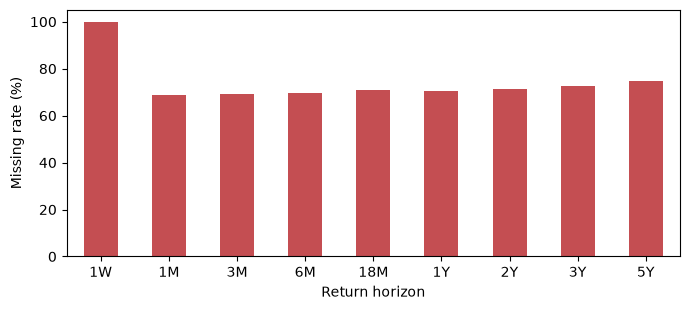

In [46]:
fig, ax = plt.subplots(figsize=(7, 3.2))
(tbl.결측률 * 100).plot.bar(ax=ax, color="#C44E52")
ax.set_xticklabels(["1W", "1M", "3M", "6M", "18M", "1Y", "2Y", "3Y", "5Y"], rotation=0)
ax.set_xlabel("Return horizon")
ax.set_ylabel("Missing rate (%)")
plt.tight_layout()
plt.show()

In [47]:
# 결측 계단 = 운용기간. 가장 긴 유효 수익률로 펀드 연차를 추정한다.
# 구간을 기간 내림차순으로 정렬해야 한다(18개월 > 1년 이므로 순서 주의)
order = ["fd_yr5_ern_r", "fd_yr3_ern_r", "fd_yr2_ern_r", "fd_mm18_ern_r", "fd_yr1_ern_r", "fd_mm6_ern_r", "fd_mm3_ern_r", "fd_mm1_ern_r", "fd_wk1_ern_r"]
age_lab = ["5년+", "3~5년", "2~3년", "18개월~2년", "1년~18개월", "6개월~1년", "3~6개월", "1~3개월", "1개월미만"]
have = uniq[order] != ""
age = pd.Series(np.select([have[c] for c in order], age_lab, default="수익률 전무"), index=uniq.index)
age.value_counts().reindex(age_lab + ["수익률 전무"]).to_frame("펀드수")

,펀드수
5년+,5979.0
3~5년,537.0
2~3년,287.0
18개월~2년,151.0
1년~18개월,142.0
6개월~1년,169.0
3~6개월,79.0
1~3개월,56.0
1개월미만,NaN
수익률 전무,16276.0


In [48]:
print("추정 신규 펀드(1년 미만 이력):", int(age.isin(["6개월~1년", "3~6개월", "1~3개월", "1개월미만"]).sum()))
print("수익률이 전혀 없는 펀드      :", int((age == "수익률 전무").sum()))
uniq.loc[age == "수익률 전무", ["itm_no", "itm_nm", "sale_yn", "fd_nast_suma"]].head(8)

추정 신규 펀드(1년 미만 이력): 304
수익률이 전혀 없는 펀드      : 16276


,itm_no,itm_nm,sale_yn,fd_nast_suma
0,KR5010101611,크리스탈신종MMFE1-1비주식,판매완료,
1,KR5010151053,스페셜단기43호,판매완료,
2,KR5010151901,서울D프로단기1,판매완료,
3,KR5010201043,스페셜중기41호,판매완료,
4,KR5010201933,D스페셜중기주식20,판매완료,
5,KR5010251006,서울장기6,판매완료,
6,KR5010251025,프로장기5,판매완료,
7,KR5010251050,프로장기30,판매완료,


> **시사점:** 펀드 기준 결측률이 1주 31.8% → 5년 49.9%로 단조 증가하는 **전형적 운용기간 계단**이다. 즉 장기 수익률 결측은 데이터 품질 문제가 아니라 **"아직 그 기간을 운용하지 않았다"** 는 사실이며, 가장 긴 유효 구간으로 펀드 연차를 역산할 수 있다. 다만 **최단 구간(1주)조차 결측인 펀드가 3,536개(31.7%)** 로 가장 큰 덩어리이며, 예시를 보면 대부분 `판매완료` 상태다 — 이들은 신규가 아니라 **청산/판매종료된 잔존 레코드**다. 또 18개월·2년·3년·5년 수익률의 최솟값이 -3,000%~-4,000%대로 **명백히 비정상적인 극단값**이 섞여 있어(누적수익률 계산 오류 추정) 수익률 기반 랭킹 질의에는 값 범위 검증이 필수다. RAG는 "3년 수익률 없음"을 "정보 없음"이 아니라 "운용 3년 미만 또는 판매종료"로 구분해 답해야 한다.

## 10. 벤치마크 — 지수 엔티티 후보

In [49]:
print("bmrk_nm 고유:", uniq.bmrk_nm.nunique(), "/ bmrk_eng_nm 고유:", uniq.bmrk_eng_nm.nunique())
print("결측:", int((uniq.bmrk_nm == "").sum()))
uniq.bmrk_nm.replace("", "(결측)").value_counts().head(20).to_frame("펀드수")

bmrk_nm 고유: 390 / bmrk_eng_nm 고유: 387
결측: 12395


,펀드수
bmrk_nm,
(결측),12395
KOSPI200,1522
MSCI ACWI CR 50% + 종합채권01Y 50%,816
KOSPI200 25% + 종합채권01Y 75%,564
MSCI ACWI,412
종합채권02Y 90%,340
MSCI ACWI CR 25% + 종합채권01Y 75%,309
채권종합지수 1~2년,285
중소형지수,243


In [50]:
# 합성 벤치마크('A 50% + B 50%')와 단일 지수 분리
comp = uniq.bmrk_nm.str.contains(r"\+|%", regex=True)
print("합성 벤치마크(가중 조합) 펀드:", int(comp.sum()), "(%.1f%%)" % (comp.mean() * 100))
print("단일 지수 벤치마크 펀드   :", int((~comp).sum()))
print("\n단일 지수 상위:")
print(uniq.loc[~comp, "bmrk_nm"].value_counts().head(15).to_string())

합성 벤치마크(가중 조합) 펀드: 5402 (22.8%)
단일 지수 벤치마크 펀드   : 18274

단일 지수 상위:
bmrk_nm
                                    12395
KOSPI200                             1522
MSCI ACWI                             412
채권종합지수 1~2년                           285
중소형지수                                 243
CALL                                  218
MSCI CHINA                            203
코스피 고배당 50                            164
제로인 대안투자기대수익지수                        164
종합채권 1~2년                             129
MSCI ACWI Information Technology      126
종합채권 3개월~1년                           107
MSCI AC ASIA PACIFIC ex JAPAN         103
S&P 500                                98
MSCI NORTH AMERICA                     97


In [51]:
# 합성 벤치마크를 구성요소로 분해하면 실제 지수 엔티티 수는 얼마인가
parts = uniq.bmrk_nm.str.split("+").explode().str.replace(r"\s*\d+(\.\d+)?%\s*", "", regex=True).str.strip()
parts = parts[parts != ""]
print("분해 후 고유 지수명:", parts.nunique(), "(원본 조합 문자열 %d종에서)" % uniq.bmrk_nm.nunique())
parts.value_counts().head(20).to_frame("등장 횟수")

분해 후 고유 지수명: 328 (원본 조합 문자열 390종에서)


,등장 횟수
bmrk_nm,
KOSPI200,2868
종합채권01Y,2103
MSCI ACWI CR,1408
CALL,488
MSCI ACWI,484
종합채권02Y,348
Call,288
채권종합지수 1~2년,285
MSCI CHINA,268


> **시사점:** `bmrk_nm` 391종 중 **47.7%(5,309펀드)가 `MSCI ACWI CR 50% + 종합채권01Y 50%` 같은 가중 합성 문자열**이라, 문자열 그대로 두면 지수 엔티티가 조합 수만큼 폭발한다. `+`와 `%`로 분해하면 391종 → 고유 지수 330종이 되고 `KOSPI200`이 2,817회로 최다 등장 지수임이 드러난다. 다만 분해 결과에도 `CALL`/`Call`, `종합채권01Y`/`종합채권 01Y`/`KIS채권종합01Y` 같은 **동일 지수의 표기 흔들림**이 남아 있어 지수 노드 생성 전 정규화 사전이 필요하다. 온톨로지에서는 **`BenchmarkIndex` 노드와 `BenchmarkComposition`(지수+비중) 중간 노드로 분리**해야 "KOSPI200을 추종하는 펀드"류 질의가 합성 벤치마크 펀드까지 포괄한다. ETF의 `cu_base_index`(국내 95% 결측)와 달리 펀드 벤치마크는 결측이 없어, **지수 엔티티의 주요 공급원은 ETF가 아니라 공모펀드 쪽**이다.

## 11. ★ 보수·수수료 — 07-11에서 "컬럼 부재로 답변 불가"였던 축

In [52]:
fee_cols = ["trusc_rwrd_r", "sale_co_rwrd_r", "or_co_rwrd_r", "ofwk_trus_rwrd_r", "fd_prsv_r"]
pd.DataFrame(
    {
        "한글명": [ko.get(c, "") for c in fee_cols],
        "결측률": [round((uniq[c] == "").mean(), 4) for c in fee_cols],
        "고유값수": [int(uniq[c][uniq[c] != ""].nunique()) for c in fee_cols],
        "min": [num(uniq[c]).min() for c in fee_cols],
        "중앙값": [round(num(uniq[c]).median(), 4) for c in fee_cols],
        "max": [num(uniq[c]).max() for c in fee_cols],
    },
    index=fee_cols,
)

,한글명,결측률,고유값수,min,중앙값,max
trusc_rwrd_r,신탁업자보수,0.0,96,0.0,0.30,7.0
sale_co_rwrd_r,판매회사보수,0.0,769,0.0,3.00,25.0
or_co_rwrd_r,집합투자업자보수,0.0,754,0.0,2.88,300.0
ofwk_trus_rwrd_r,일반사무관리보수,0.0,70,0.0,0.14,2.0
fd_prsv_r,보전율,0.0,790,0.0,2.90,25.0


In [53]:
# ⚠️ 단위 검증. 값을 그대로 %로 읽으면 판매보수 중앙값이 4.7%가 되어 현실과 맞지 않는다.
live = uniq[(uniq.prvo_pbff_desc == "공모") & (uniq.sale_yn == "판매중") & (uniq.thco_sale_yn == "Y")].copy()
live["보수합"] = sum(num(live[c]).fillna(0) for c in ["trusc_rwrd_r", "or_co_rwrd_r", "sale_co_rwrd_r", "ofwk_trus_rwrd_r"])
print("보수 4종 단순 합(원본 단위) — 공모·판매중", len(live), "펀드")
print(live.보수합.describe().round(3).to_string())
print("\n→ 이대로 '%'라 읽으면 평균 총보수 10%대. 국내 공모펀드 현실과 맞지 않는다.")

보수 4종 단순 합(원본 단위) — 공모·판매중 8550 펀드
count    8550.000
mean       10.723
std         5.791
min         0.000
25%         6.200
50%        10.100
75%        14.800
max        30.900

→ 이대로 '%'라 읽으면 평균 총보수 10%대. 국내 공모펀드 현실과 맞지 않는다.


In [54]:
# ★ 내부 교차검증: 펀드↔ETF 중복 상품(ksd_itm_no 조인)의 LSEG ter(실제 총보수율 %)와 대조한다.
import json
lseg = json.loads((ROOT / "data" / "lseg_static_metadata.json").read_text(encoding="utf-8"))
etf = pd.read_csv(CSV / "PREF01N001_etf_kr_master_20260824.csv", dtype=str, keep_default_na=False)
etf["ter"] = pd.to_numeric(etf.pd_itm_no_ma.str[1:].map(lambda k: (lseg.get(k) or {}).get("ter")), errors="coerce")
mm = uniq.merge(etf[["pd_itm_no", "ter", "pd_abrv_nm"]], left_on="ksd_itm_no", right_on="pd_itm_no")
mm["보수합"] = sum(num(mm[c]).fillna(0) for c in ["trusc_rwrd_r", "or_co_rwrd_r", "sale_co_rwrd_r", "ofwk_trus_rwrd_r"])
z = mm[(mm.보수합 > 0) & mm.ter.notna()].copy()
z["보수합÷10"] = z.보수합 / 10
z["오차"] = (z["보수합÷10"] - z.ter).abs()
print("ETF와 중복되며 보수값이 채워진 펀드:", len(z))
print("보수합을 그대로 퍼센트로 볼 때 ter 대비 배율 중앙값: %.1f배" % (z.보수합 / z.ter).median())
print("보수합÷10 vs ter 절대오차 중앙값: %.4f %%p" % z.오차.median())
z[["pd_abrv_nm", "보수합", "보수합÷10", "ter", "오차"]].head(12)

ETF와 중복되며 보수값이 채워진 펀드: 67
보수합을 그대로 퍼센트로 볼 때 ter 대비 배율 중앙값: 11.3배
보수합÷10 vs ter 절대오차 중앙값: 0.0680 %p


,pd_abrv_nm,보수합,보수합÷10,ter,오차
1,KODEX 차이나심천ChiNext(합성),4.9,0.49,0.47,0.02
8,TIGER 200 에너지화학,4.0,0.40,0.34,0.06
12,ACE 삼성그룹섹터가중,4.0,0.40,0.15,0.25
18,TIGER 은행,5.2,0.52,0.46,0.06
24,KODEX KTOP30,4.0,0.40,0.25,0.15
38,PLUS 코스피50,4.9,0.49,0.33,0.16
40,TIGER 인도니프티50레버리지(합성),5.9,0.59,0.58,0.01
42,KODEX 200선물인버스2X,4.9,0.49,0.64,0.15
45,PLUS 스마트베타Quality채권혼합,4.9,0.49,0.20,0.29
46,PLUS 고배당주채권혼합,4.9,0.49,0.20,0.29


> **단위 확정:** `보수합 ÷ 10`이 LSEG `ter`(실제 총보수율 %)와 같은 자릿수로 맞아떨어진다
> (예: `KODEX 차이나심천ChiNext(합성)` 4.9 → 0.49% vs ter 0.47%, `TIGER 인도니프티50레버리지(합성)` 5.9 → 0.59% vs ter 0.58%).
> 즉 **이 보수 컬럼들의 단위는 %가 아니라 천분율(‰)이며, 10으로 나눠야 연 보수율(%)이 된다.**
> 잔차(중앙 0.07%p)는 LSEG `ter`가 실제 부담 총비용인 반면 이 컬럼은 약관상 보수라 생기는 정상 차이로 본다.

In [55]:
live["연보수율_pct"] = live.보수합 / 10
print("연 보수율(%) — 공모·판매중", len(live), "펀드")
print(live.연보수율_pct.describe().round(4).to_string())
print("\n채널별 중앙 연보수율(%):")
print(live.groupby(live.han_clas_sales_channel.replace("", "(결측)")).연보수율_pct.median().round(3).to_string())
print("\n가장 싼 펀드 10:")
print(live.nsmallest(10, "연보수율_pct")[["itm_nm", "han_clas_nm", "연보수율_pct"]].to_string())

연 보수율(%) — 공모·판매중 8550 펀드
count    8550.0000
mean        1.0723
std         0.5791
min         0.0000
25%         0.6200
50%         1.0100
75%         1.4800
max         3.0900

채널별 중앙 연보수율(%):
han_clas_sales_channel
(결측)    0.910
오프라인    1.240
온라인     0.792
직판      0.180

가장 싼 펀드 10:
                                itm_nm          han_clas_nm  연보수율_pct
21037      디더블유에스코리아채권투자신탁1-1호 Class P                          0.000
4803   미래에셋퇴직연금솔로몬증권자투자신탁1호(채권) 종류 C-F   수수료미징구-직판-퇴직연금, 펀드     0.015
9300          하나클래스원특별자산투자신탁(3호) 종류 C1     수수료미징구-오프라인-보수체감     0.029
12068             다올전단채증권투자신탁[채권] 종류CW        수수료미징구-오프라인-랩     0.035
14400            미래에셋국공채전용MMFA1호(국공채)F  수수료미징구-오프라인-랩, 펀드 등     0.040
5985    미래에셋국공채전용MMFA1호(국공채)C-P2e (퇴직)      수수료미징구-온라인-퇴직연금     0.050
23225   iM에셋 인덱스플러스증권자투자신탁1호(주식-파생형)Cf       수수료미징구-오프라인-기관     0.050
1711      미래에셋프리미엄크레딧초단기증권투자신탁(채권) 종류F      수수료미징구-직판-랩, 펀드     0.060
9613      KB 법인용 MMF I-2호(국공채) C-W 클래스   수수료미징구-오프라인-랩,금전신탁     0.060
12284        

> **시사점:** 07-11 배포본에서 **"펀드 수수료(선취/후취/총보수) — 해당 컬럼 없음 → 답변 불가"** 로 못박았던 항목이 08-24 배포본에서 **결측 0%로 제공된다.** `trusc_rwrd_r`(신탁업자)·`or_co_rwrd_r`(집합투자업자)·`sale_co_rwrd_r`(판매회사)·`ofwk_trus_rwrd_r`(일반사무관리) 4종을 합산하면 연 보수율이 되고, `han_clas_fee_type`이 선취/후취/미징구를 구분한다. **"보수가 가장 싼 펀드" 류 질의가 답변 가능으로 전환**된다.
>
> ⚠️ **단 단위가 천분율(‰)이다. 10으로 나누지 않고 답하면 "총보수 10%짜리 펀드"라는 자릿수 오답이 나간다.** 스키마 코멘트에는 단위 표기가 없으므로 이 변환 규칙을 `metadata/business_rules.json`에 못박아야 한다. 온라인 클래스가 오프라인보다 판매보수가 낮다는 상식적 서열도 성립해(온라인 < 오프라인) 값 자체는 신뢰 가능하다.
> 또 `fd_prsv_r`(보전율)은 전 행에서 `sale_co_rwrd_r`과 값이 동일해 **독립 정보가 아니다** — 보수 합산에 넣으면 판매보수가 이중 계상된다.

## 종합

| 항목 | 실측 | 온톨로지/RAG 영향 |
|---|---|---|
| **그레인** | 23,676행 = 23,676펀드 (itm_no 단독 유일키) | ★ 8.53배 왜곡 함정 **해소** |
| **사모 혼재** | 8,960펀드(37.8%) | ★ 102행 → 88배. **1순위 필수 필터** |
| 공모 펀드 수 | 14,716 / 당사 판매중 8,550 | "공모펀드 몇 개" 정답 = 14,716 |
| prfd_attr_cds | 결합 문자열 + search_text에 한글 라벨 | ★ 코드 의미를 원천에서 직접 읽음 |
| 보수·수수료 | 신탁/운용/판매 보수 결측 0% | ★ 답변 불가 → **가능**. 단 값 범위 검증 필수 |
| 클래스 계층 | `han_clas_nm` 195종, 공모·판매중 결측 <2% | ★ 정규식 추정 → **직접 값** |
| 축 재현 | 6축 중 완전 3축 + 부분 2축 | listingType만 여전히 불가 |
| or_attr_desc | 한글명 14종, 파생상품 2,302 | ★ 미매핑 코드 '06' **소멸** |
| 위험등급 | 제로인 1~6, 공모·판매중 결측 0.2% | 코드 기준 서열이 ETF와 동일 → 코드로 통합 |
| 벤치마크 | 389종, 전체 결측 52.4% / 공모·판매중 0.0% | 모집단 기준으로 결측률 인용할 것 |
| 자산구성비 | `zrin_*_cmst_rt` 8종 신설 | 국내주식/해외주식/채권 비중 질의 가능 |